## Energy consumption of two opposing vessels passing a lock
In this notebook, we simulate a lock complex on a network. We model two opposing directed vessels that have to pass the complex. Hence, when one vessel is being levelled, the other vessel has to wait. We quantify energy consumption with the Energy Module.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import numpy as np
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core import ExtraMetadata
from opentnsim.core.logutils import logbook2eventtable, eventtable2gdf
from opentnsim.core.utils import create_object
from opentnsim.core.visualizations import generate_vessel_gantt_chart, plot_gdf_eventtable

# import of util for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of mixins and utils important for energy and fuel consumption
from opentnsim.energy.mixins import ConsumesEnergy
from opentnsim.energy.logutils import add_energy_attributes_to_eventtable,add_fuel_attributes_to_event_table

# import of mixins important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt

# package(s) needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev105+gc0ed3023c.d20260415


#### 0. Create environment
We create an environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
We create a simple graph, just like notebooks 201, 202, and 203.

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087') #equidistant WGS84 in meters
wgs84rad = pyproj.CRS('4326') #radial WGS84 (used in GPS)

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.Graph()

# add nodes
geometry_m = Point(-5000,0)
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_node('0',geometry=geometry) #we need to have a geometry in WGS84
geometry_m = Point(5000,0)
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_node('1',geometry=geometry) #we need to have a geometry in WGS84

# add edges
geometry_m = LineString([Point(-5000, 0),Point(5000, 0)])
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_edge('0','1', geometry = geometry, weight=1, length_m=10000, GeneralDepth = 6.5) #we need to have a geometry in WGS84 and a length in meters

# add graph to environment
env.graph = graph

We plot the graph

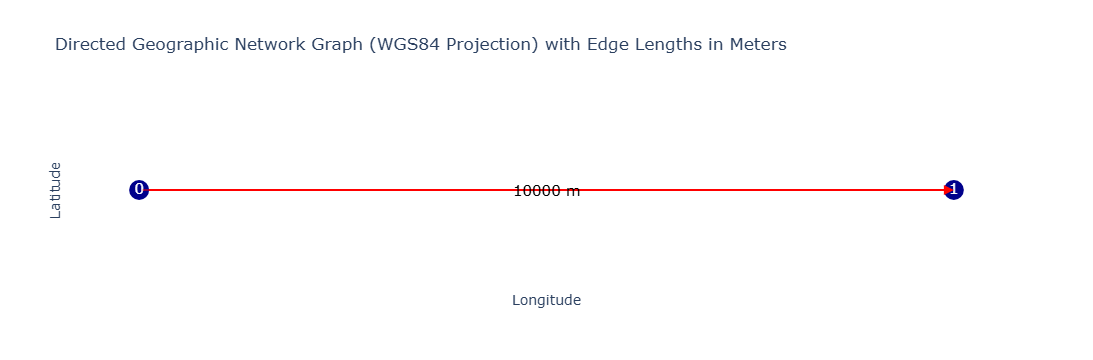

In [4]:
plot_graph(graph)

#### 1+ Adding infrastructure
We add the lock complex

In [5]:
#We use approach a)
lock_chamber = IsLockChamber(env=env,
                             lock_length = 400,
                             lock_width = 50,
                             lock_depth = 10,
                             name='Lock',      
                             edge = ('0','1'),
                             distance_from_start_node_to_lock_gate_A = 4800.,
                             distance_from_end_node_to_lock_gate_B = 4800.)

In [6]:
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   orientation = 0,
                                   distance_from_edge_start = 0) #Waiting area A will be located on node 1

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   orientation = 1,
                                   distance_from_edge_start = 0) #Waiting area B will be located on node 1

In [7]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We create agents according to earlier notebooks.

In [8]:
Vessel = create_object(
    "Vessel",
    (
        LockComplexTraversable,     # allows to interact with a lock
        ConsumesEnergy,             # allows to calculate energy consumption 
        ExtraMetadata
    ),
)

In [9]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

We create two vessels with opposing directions

In [10]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00'), # required by PassesLockComplex
    "safety_margin": 0.2,       
    "h_squat": True,           
    "P_installed": 1750.0, 
    "P_tot_given": None, 
    "bulbous_bow": False, 
    "karpov_correction": True, 
    "P_hotel_perc": 0.05, 
    "P_hotel": None,
    "x": 2,
    "L_w": 3.0 ,
    "C_B": 0.85,
    "C_year": 1990,
}  
vessel_1 = Vessel(**data_vessel_1)

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['1']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "1", "0"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00'), # required by PassesLockComplex
    "safety_margin": 0.2,       
    "h_squat": True,           
    "P_installed": 1750.0, 
    "P_tot_given": None, 
    "bulbous_bow": False, 
    "karpov_correction": True, 
    "P_hotel_perc": 0.05, 
    "P_hotel": None,
    "x": 2,
    "L_w": 3.0 ,
    "C_B": 0.85,
    "C_year": 1990,
}  
vessel_2 = Vessel(**data_vessel_2)

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2));

#### 3. Run simulation
We run the simulation

In [11]:
env.run()

#### 4. Inspect output

##### Gantt chart
We confirm the vessel-infrastructure behaviour.

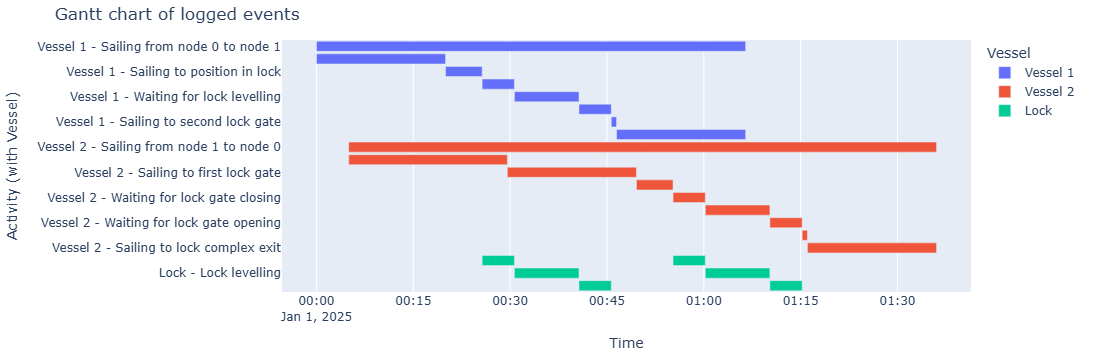

In [12]:
# eventtable for only vessels,
df_eventtable = logbook2eventtable([vessel_1, vessel_2, lock_chamber])
generate_vessel_gantt_chart(df_eventtable)

##### Energy consumption
To quantify the energy consumption, we have to create an event table and add energy attributes to it.

In [13]:
# eventtable for only vessels
df_eventtable = logbook2eventtable([vessel_1, vessel_2])

# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1, vessel_2])        

# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to first lock gate,POINT (-0.0449157642059761 0),POINT (-0.001796630568239 0),2025-01-01 00:00:00,2025-01-01 00:20:00,4800.0,1200.000000,6.023341,NaN,0.0,1990.0,1028.369405,1028.369405,1750.0,342.789802
1,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to position in lock,POINT (-0.001796630568239 0),POINT (0.0013474729261793 0),2025-01-01 00:20:00,2025-01-01 00:25:40,350.0,340.172786,9.980042,50.0,0.0,1990.0,104.006606,104.006606,1750.0,9.827838
2,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate closing,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:25:40,2025-01-01 00:30:40,0.0,300.000000,10.000000,50.0,0.0,1990.0,87.500000,87.500000,1750.0,7.291667
3,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Waiting for lock levelling,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:30:40,2025-01-01 00:40:40,0.0,600.000000,10.000000,50.0,0.0,1990.0,87.500000,87.500000,1750.0,14.583333
4,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate opening,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:40:40,2025-01-01 00:45:40,0.0,300.000000,10.000000,50.0,0.0,1990.0,87.500000,87.500000,1750.0,7.291667
5,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to second lock gate,POINT (0.0013474729261793 0),POINT (0.001796630568239 0),2025-01-01 00:45:40,2025-01-01 00:46:29,50.0,48.596113,9.980042,50.0,0.0,1990.0,104.006605,104.006605,1750.0,1.403977
6,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to lock complex exit,POINT (0.001796630568239 0),POINT (0.0449157642059761 0),2025-01-01 00:46:29,2025-01-01 01:06:29,4800.0,1200.000000,6.023341,NaN,0.0,1990.0,1028.369405,1028.369405,1750.0,342.789802
7,630de049-7190-4a56-bc1e-bb21018eee18,Vessel 2,Sailing from node 1 to node 0,Waiting for lock operation,POINT (0.0449157642059761 0),POINT (0.0449157642059761 0),2025-01-01 00:05:00,2025-01-01 00:29:34,0.0,1473.768898,6.500000,NaN,0.0,1990.0,87.500000,87.500000,1750.0,35.820772
8,630de049-7190-4a56-bc1e-bb21018eee18,Vessel 2,Sailing from node 1 to node 0,Sailing to first lock gate,POINT (0.0449157642059761 0),POINT (0.001796630568239 0),2025-01-01 00:29:34,2025-01-01 00:49:34,4800.0,1200.000000,6.023341,NaN,0.0,1990.0,1028.369405,1028.369405,1750.0,342.789802
9,630de049-7190-4a56-bc1e-bb21018eee18,Vessel 2,Sailing from node 1 to node 0,Sailing to position in lock,POINT (0.001796630568239 0),POINT (-0.0013474729261793 0),2025-01-01 00:49:34,2025-01-01 00:55:14,350.0,340.172786,9.980042,50.0,0.0,1990.0,104.006606,104.006606,1750.0,9.827838


In addition, we need to add fuel attributes to the event table:

In [14]:
# add fuel attributes to the minimum event table with energy attributes
df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2])

pd.set_option('display.max_columns', None)
df_eventtable_energy_fuel

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s)
0,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to first lock gate,POINT (-0.0449157642059761 0),POINT (-0.001796630568239 0),2025-01-01 00:00:00,2025-01-01 00:20:00,4800.0,1200.000000,6.023341,NaN,0.0,1990.0,1028.369405,1028.369405,1750.0,342.789802,77108.459445,16.064262,64.257050,244644.112239,137.115921,3436.113965,50.967523,0.028566,0.715857,203.870094,0.114263,2.863428
1,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to position in lock,POINT (-0.001796630568239 0),POINT (0.0013474729261793 0),2025-01-01 00:20:00,2025-01-01 00:25:40,350.0,340.172786,9.980042,50.0,0.0,1990.0,104.006606,104.006606,1750.0,9.827838,2210.711773,6.316319,6.498791,7013.985535,3.931135,98.513933,20.039959,0.011232,0.281468,20.618891,0.011556,0.289600
2,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate closing,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:25:40,2025-01-01 00:30:40,0.0,300.000000,10.000000,50.0,0.0,1990.0,87.500000,87.500000,1750.0,7.291667,1640.215609,NaN,5.467385,5203.956796,2.916667,73.091433,NaN,NaN,NaN,17.346523,0.009722,0.243638
3,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Waiting for lock levelling,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:30:40,2025-01-01 00:40:40,0.0,600.000000,10.000000,50.0,0.0,1990.0,87.500000,87.500000,1750.0,14.583333,3280.431218,NaN,5.467385,10407.913592,5.833333,146.182865,NaN,NaN,NaN,17.346523,0.009722,0.243638
4,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate opening,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:40:40,2025-01-01 00:45:40,0.0,300.000000,10.000000,50.0,0.0,1990.0,87.500000,87.500000,1750.0,7.291667,1640.215609,NaN,5.467385,5203.956796,2.916667,73.091433,NaN,NaN,NaN,17.346523,0.009722,0.243638
5,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to second lock gate,POINT (0.0013474729261793 0),POINT (0.001796630568239 0),2025-01-01 00:45:40,2025-01-01 00:46:29,50.0,48.596113,9.980042,50.0,0.0,1990.0,104.006605,104.006605,1750.0,1.403977,315.815970,6.316319,6.498791,1001.997942,0.561591,14.073419,20.039959,0.011232,0.281468,20.618891,0.011556,0.289600
6,906282f1-a34f-4a05-b5be-fc0674e2119f,Vessel 1,Sailing from node 0 to node 1,Sailing to lock complex exit,POINT (0.001796630568239 0),POINT (0.0449157642059761 0),2025-01-01 00:46:29,2025-01-01 01:06:29,4800.0,1200.000000,6.023341,NaN,0.0,1990.0,1028.369405,1028.369405,1750.0,342.789802,77108.459445,16.064262,64.257050,244644.112239,137.115921,3436.113965,50.967523,0.028566,0.715857,203.870094,0.114263,2.863428
7,630de049-7190-4a56-bc1e-bb21018eee18,Vessel 2,Sailing from node 1 to node 0,Waiting for lock operation,POINT (0.0449157642059761 0),POINT (0.0449157642059761 0),2025-01-01 00:05:00,2025-01-01 00:29:34,0.0,1473.768898,6.500000,NaN,0.0,1990.0,87.500000,87.500000,1750.0,35.820772,8057.662502,NaN,5.467385,25564.765575,14.328309,359.066266,NaN,NaN,NaN,17.346523,0.009722,0.243638
8,630de049-7190-4a56-bc1e-bb21018eee18,Vessel 2,Sailing from node 1 to node 0,Sailing to first lock gate,POINT (0.0449157642059761 0),POINT (0.001796630568239 0),2025-01-01 00:29:34,2025-01-01 00:49:34,4800.0,1200.000000,6.023341,NaN,0.0,1990.0,1028.369405,1028.369405,1750.0,342.789802,77108.4

Like the Energy-examples, we can visualize the energy consumption per event per vessel:

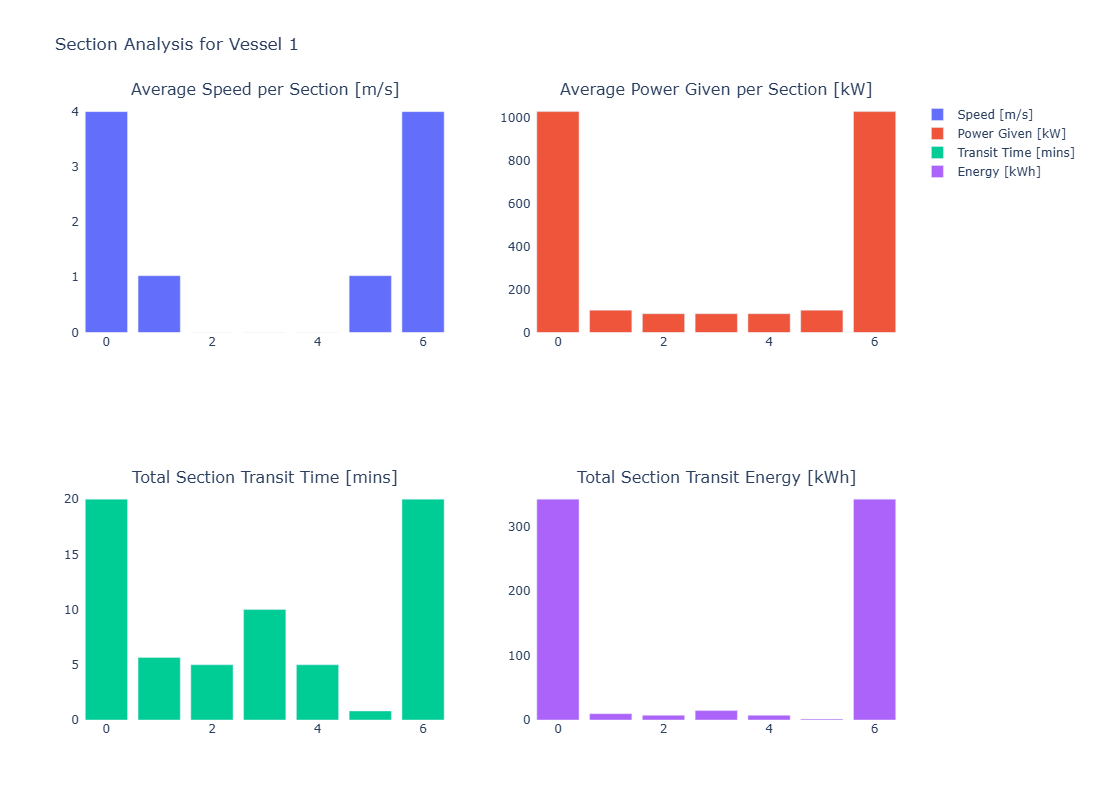

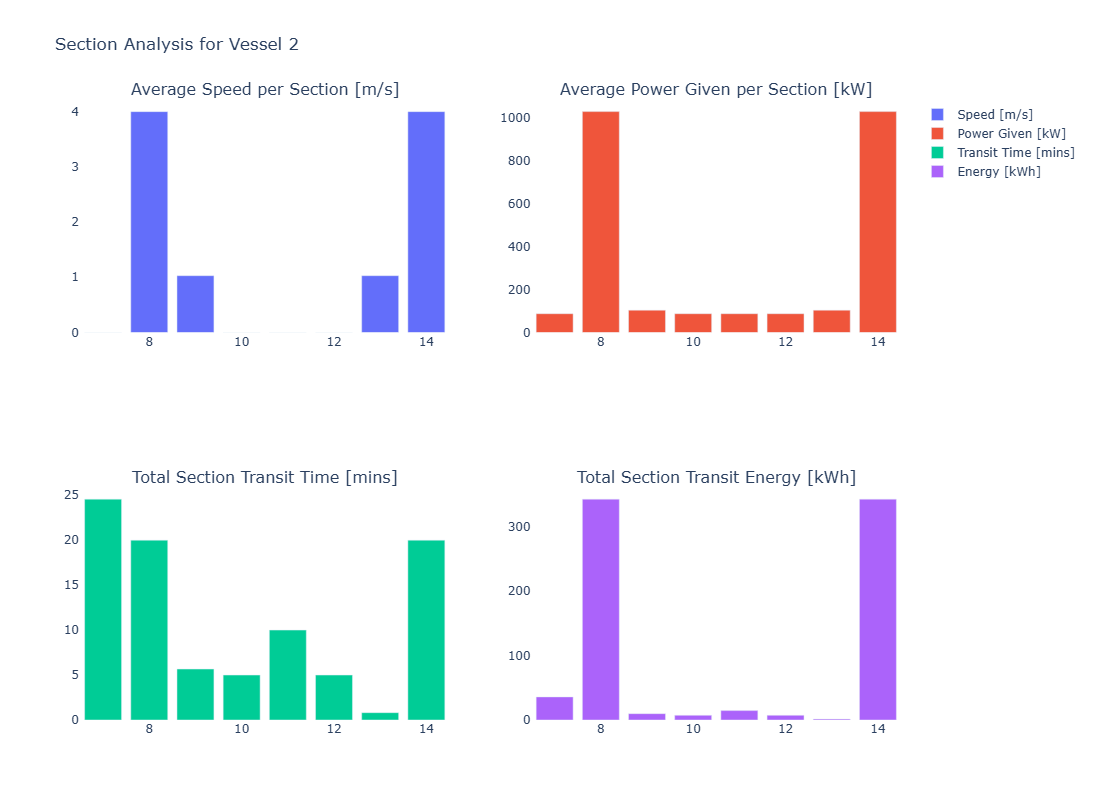

In [15]:
for vessel in [vessel_1, vessel_2]:
    df_eventtable_energy_fuel_vessel = df_eventtable_energy_fuel[df_eventtable_energy_fuel['object name'] == vessel.name]
    
    # Calculate average speed
    average_speed = df_eventtable_energy_fuel_vessel['distance (m)'] / df_eventtable_energy_fuel_vessel['duration (s)']
    
    # Calculate durations in minutes
    durations = [
        (row['stop time'] - row['start time']).total_seconds() / 60
        for _, row in df_eventtable_energy_fuel_vessel.iterrows()
    ]
    
    # Create 2x2 subplot figure
    fig = make_subplots(rows=2, cols=2, subplot_titles=[
        'Average Speed per Section [m/s]',
        'Average Power Given per Section [kW]',
        'Total Section Transit Time [mins]',
        'Total Section Transit Energy [kWh]'
    ])
    
    # Add bar charts to subplots
    fig.add_trace(go.Bar(x=average_speed.index, y=average_speed, name='Speed [m/s]'), row=1, col=1)
    fig.add_trace(go.Bar(x=average_speed.index, y=df_eventtable_energy_fuel_vessel['P_given (kW)'], name='Power Given [kW]'), row=1, col=2)
    fig.add_trace(go.Bar(x=average_speed.index, y=durations, name='Transit Time [mins]'), row=2, col=1)
    fig.add_trace(go.Bar(x=average_speed.index, y=df_eventtable_energy_fuel_vessel['total_energy (kWh)'], name='Energy [kWh]'), row=2, col=2)
    
    # Update layout
    fig.update_layout(
        height=800,
        width=1000,
        title_text=f'Section Analysis for {vessel.name}',
        plot_bgcolor='white'
    )
    
    fig.show()

We can also visualize the cumulative diesel consumption over distance:

Text(0, 0.5, 'cumulative diesel consumption (g)')

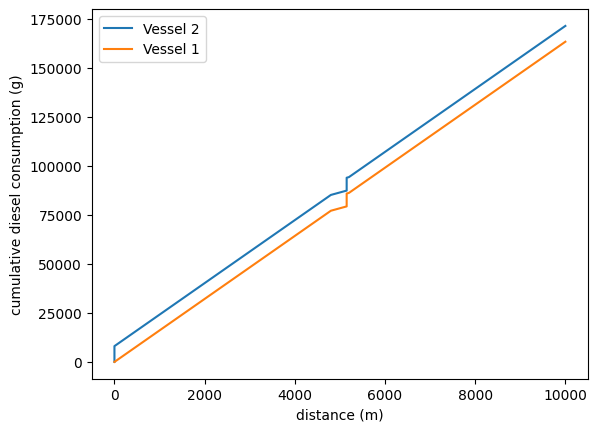

In [16]:
fig,ax = plt.subplots()
for obj_id, df_obj in df_eventtable_energy_fuel.groupby('object id'):
    dist_0 = df_obj['distance (m)'].shift(1)
    dist_0 = dist_0.fillna(0.)
    dist_cum_0 = dist_0.cumsum()
    dist_1 = df_obj['distance (m)']
    dist_cum_1 = dist_1.cumsum()
    df_obj['diesel_consumption_cum'] = df_obj['diesel_consumption (g)'].cumsum()
    diesel_consumption_cum_0 = df_obj['diesel_consumption_cum'].shift(1)
    diesel_consumption_cum_0 = diesel_consumption_cum_0.fillna(0.)
    diesel_consumption_cum_1 = df_obj['diesel_consumption_cum']
    time = pd.concat([dist_cum_0, dist_cum_1])
    consumption = pd.concat([diesel_consumption_cum_0,diesel_consumption_cum_1])
    obj_name = df_obj['object name'].mode()[0]
    df = pd.DataFrame(consumption.values, index=time, columns=[obj_name])
    df = df.sort_values(obj_name)
    df.plot(ax=ax)
ax.legend()
ax.set_ylabel('cumulative diesel consumption (g)')

And the consumption rate over time:

Text(0, 0.5, 'diesel consumption rate (g/s)')

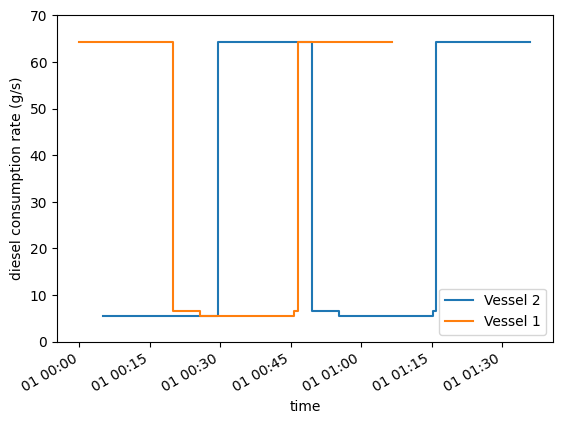

In [17]:
fig,ax = plt.subplots()
for obj_id, df_obj in df_eventtable_energy_fuel.groupby('object id'):
    obj_name = df_obj['object name'].mode()[0]
    diesel_consumption_0 = df_obj['diesel_consumption_s (g/s)'].shift(1)
    diesel_consumption_0 = diesel_consumption_0.bfill()
    diesel_consumption_1 = df_obj['diesel_consumption_s (g/s)'].shift(-1)
    diesel_consumption_1 = diesel_consumption_1.ffill()
    time = pd.concat([df_obj['start time'] - pd.Timedelta(nanoseconds=1),df_obj['stop time'] + pd.Timedelta(nanoseconds=1)])
    consumption = pd.concat([diesel_consumption_0,diesel_consumption_1])
    df = pd.DataFrame(consumption.values, index=time, columns=[obj_name])
    df = df.sort_index()
    df.plot(ax=ax)
ax.legend()
ax.set_xlabel('time')
ax.set_ylim(0,70)
ax.set_ylabel('diesel consumption rate (g/s)')

And the consumption of diesel per m:

Text(0, 0.5, 'diesel consumption per m (g/m)')

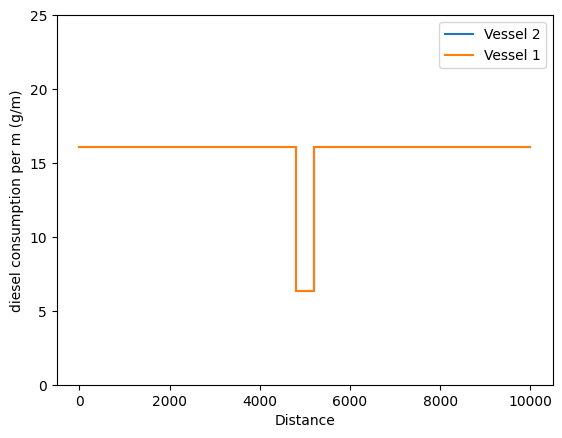

In [18]:
fig,ax = plt.subplots()
for obj_id, df_obj in df_eventtable_energy_fuel.groupby('object id'):
    obj_name = df_obj['object name'].mode()[0]
    dist_0 = df_obj['distance (m)'].cumsum().shift(1).fillna(0.)
    dist_cum_0 = dist_0.bfill()
    dist_1 = df_obj['distance (m)'].cumsum()+0.001
    dist_cum_1 = dist_1.ffill()
    diesel_consumption_0 = df_obj['diesel_consumption_m (g/m)'].shift(1)
    diesel_consumption_0 = diesel_consumption_0.bfill()
    diesel_consumption_1 = df_obj['diesel_consumption_m (g/m)'].shift(-1)
    diesel_consumption_1 = diesel_consumption_1.ffill()
    dist = pd.concat([dist_cum_0, dist_cum_1])
    consumption = pd.concat([diesel_consumption_0,diesel_consumption_1])
    df = pd.DataFrame(consumption.values, index=dist, columns=[obj_name])
    df = df.sort_index()
    df.plot(ax=ax)
ax.legend()
ax.set_xlabel('Distance')
ax.set_ylim(0,25)
ax.set_ylabel('diesel consumption per m (g/m)')

We can also plot the data spatially, aggregated over the subnodes and subedges (i.e., the nodes and edges split by the locations at which the vessels wait):

In [19]:
gdf_eventtable_energy_fuel = eventtable2gdf(df_eventtable_energy_fuel, [vessel_1, vessel_2])
gdf_eventtable_energy_fuel

,total_distance_sailed (m),total_residence_time (s),average_P_tot (kW),average_P_given (kW),average_P_installed (kW),average_engine_age (year),total_energy_consumed (kWh),total_diesel_consumed (g),total_CO2_emitted (g),total_PM10_emitted (g),total_NOX_emitted (g),average_diesel_consumption_s (g/s),average_CO2_emission_per_s (g/s),average_PM10_emission_per_s (g/s),average_NOX_emission_per_s (g/s),average_diesel_consumption_m (g/m),average_CO2_emission_per_m (g/m),average_PM10_emission_per_m (g/m),average_NOX_emission_per_m (g/m),geometry,vessel_ids
0,600.0,583.153347,104.006606,104.006606,1750.0,1990.0,19.655676,4421.423546,14027.971069,7.862270,197.027866,6.498791,20.618891,0.011556,0.289600,6.316319,20.039959,0.011232,0.281468,"LINESTRING (-0.00135 0, 0.00135 0)","[906282f1-a34f-4a05-b5be-fc0674e2119f, 630de04..."
1,100.0,97.192224,104.006606,104.006606,1750.0,1990.0,11.231815,2526.527740,8015.983465,4.492726,112.587352,6.498791,20.618891,0.011556,0.289600,6.316319,20.039959,0.011232,0.281468,"LINESTRING (-0.0018 0, -0.00135 0)","[906282f1-a34f-4a05-b5be-fc0674e2119f, 630de04..."
2,9600.0,2400.000000,1028.369405,1028.369405,1750.0,1990.0,685.579604,154216.918890,489288.224479,274.231841,6872.227929,64.257050,203.870094,0.114263,2.863428,16.064262,50.967523,0.028566,0.715857,"LINESTRING (-0.04492 0, -0.0018 0)","[906282f1-a34f-4a05-b5be-fc0674e2119f, 630de04..."
3,100.0,97.192225,104.006606,104.006606,1750.0,1990.0,11.231815,2526.527743,8015.983476,4.492726,112.587352,6.498791,20.618891,0.011556,0.289600,6.316319,20.039959,0.011232,0.281468,"LINESTRING (0.00135 0, 0.0018 0)","[906282f1-a34f-4a05-b5be-fc0674e2119f, 630de04..."
4,9600.0,2400.000000,1028.369405,1028.369405,1750.0,1990.0,685.579604,154216.918890,489288.224479,274.231841,6872.227929,64.257050,203.870094,0.114263,2.863428,16.064262,50.967523,0.028566,0.715857,"LINESTRING (0.0018 0, 0.04492 0)","[906282f1-a34f-4a05-b5be-fc0674e2119f, 630de04..."
5,0.0,1200.000000,87.500000,87.500000,1750.0,1990.0,29.166667,6560.862436,20815.827184,11.666667,292.365730,5.467385,17.346523,0.009722,0.243638,0.000000,0.000000,0.000000,0.000000,POINT (-0.00135 0),[630de049-7190-4a56-bc1e-bb21018eee18]
6,0.0,1200.000000,87.500000,87.500000,1750.0,1990.0,29.166667,6560.862436,20815.827184,11.666667,292.365730,5.467385,17.346523,0.009722,0.243638,0.000000,0.000000,0.000000,0.000000,POINT (0.00135 0),[906282f1-a34f-4a05-b5be-fc0674e2119f]
7,0.0,1473.768898,87.500000,87.500000,1750.0,1990.0,35.820772,8057.662502,25564.765575,14.328309,359.066266,5.467385,17.346523,0.009722,0.243638,0.000000,0.000000,0.000000,0.000000,POINT (0.04492 0),[630de049-7190-4a56-bc1e-bb21018eee18]


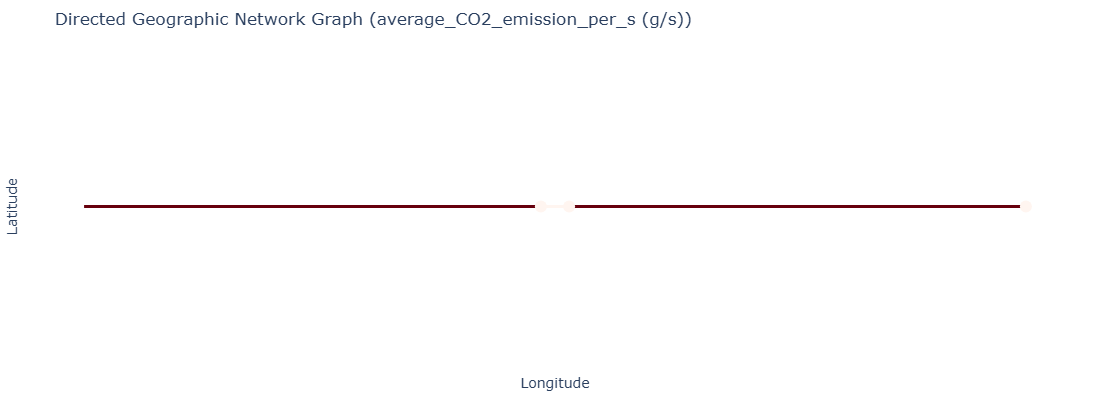

In [20]:
fig = plot_gdf_eventtable(gdf_eventtable_energy_fuel, attr='average_CO2_emission_per_s (g/s)')
fig.show()